In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
import warnings
import traceback

if '../' not in sys.path:
    sys.path.append('../')

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as lines
from scipy.interpolate import interp1d
from scipy.optimize import root_scalar

plt.style.use('../input/physrev.mplstyle')
plt.rcParams['figure.dpi'] = "300"

In [4]:
def load_csv(file_name, skip_header=0):
    plot_data = np.genfromtxt(file_name, delimiter=',', skip_header=skip_header)
    
    x = list(zip(*plot_data))[0]
    y = list(zip(*plot_data))[1]
    
    return x, y

### ACT Stuff

In [5]:
act_central_value = 2.89
Dneff_act_68_errorbar = 0.11

### directory with N_eff results

In [6]:
highmass = False

In [7]:
# adm_results_dir = '/Users/duncan/scratch/adm_scans/adm_scan_fine/'
results_dir = '/Users/duncan/src/mcp_boltzmann/output/results/anapole/R_3.0/'


### Loop over directories to find all parameter points and load results

In [15]:
Q_min = 1e-11
Q_max = 1e-4

num_Q = 50
charge_list = np.geomspace(Q_min, Q_max, num_Q)

In [16]:
# N_eff_min_cut = 2.7

In [17]:
mchi_dirs = []

for name in os.listdir(results_dir):
    if os.path.isdir(os.path.join(results_dir, name)):
        mchi_dirs.append(os.path.join(results_dir, name))


In [86]:
N_Q = 50
num_param_points = len(mchi_dirs)*N_Q

m_chi = np.zeros(num_param_points)
charges = np.zeros(num_param_points)
N_eff = np.zeros(num_param_points)

T_gam_bsm_f = np.zeros(num_param_points)
T_star = np.zeros(num_param_points)
xi_star = np.zeros(num_param_points)


R_Tnu_Tgam = np.zeros(num_param_points)
R_Tdark_Tgam = np.zeros(num_param_points)
R_Tgam_bsm_Tgam_sm = np.zeros(num_param_points)

res_ind = 0

for (i, res_dir) in enumerate(mchi_dirs):
    result_files = [f for f in os.listdir(res_dir) if f.endswith('.npz')]
    
    for (j, rf) in enumerate(result_files):
        result = np.load(os.path.join(res_dir, rf))
        result_txt_fname = rf.split('.npz')[0] + '.txt'

        #very hacky way to get temperature ratios from text files
        result_txt = np.genfromtxt(
            os.path.join(res_dir, rf.split('.npz')[0] + '.txt'), 
            delimiter='=', 
            skip_footer=1,
            usecols=1
        )

        ratio_Tnu_Tg = result_txt[8]
        ratio_Td_Tg = result_txt[9]
        ratio_Tgbsm_Tgsm = result_txt[10]

        R_Tnu_Tgam[res_ind] = ratio_Tnu_Tg
        R_Tdark_Tgam[res_ind] = ratio_Td_Tg
        R_Tgam_bsm_Tgam_sm[res_ind] = ratio_Tgbsm_Tgsm 

        T_gam_bsm_f[res_ind] = result['T_gam_bsm'][-1]
        

        m_chi[res_ind] = result['m_chi']
        # m_dp[res_ind] = result['m_dp']
        charges[res_ind] = result['Q']
        N_eff[res_ind] = result['N_eff_bsm']
        
        # Delta_N_eff[res_ind] = result['Delta_Neff']
        # Delta_N_eff_dso[res_ind] = result['DNeff_dso']

        T_gam = result['T_gam_bsm']
        T_nu = result['T_nu_bsm']
        T_dark = result['T_dark_bsm']

        T_dark_of_T_gam = interp1d(T_gam, T_dark)
        

        T_star[res_ind] = root_scalar(lambda T: T_dark_of_T_gam(T) - 3.0*m_chi[res_ind], bracket=(T_gam[-1], T_gam[0])).root
        xi_star[res_ind] =  T_dark_of_T_gam(T_star)/T_star

        

        res_ind += 1

failed_jobs = len(np.where(m_chi == 0)[0])

ValueError: A value (0.0) in x_new is below the interpolation range's minimum value (0.00014158149788739253).

In [84]:
sel = np.where(m_chi > 0)

m_chi = m_chi[sel]
charges = charges[sel]
N_eff = N_eff[sel]
T_gam_bsm_f = T_gam_bsm_f[sel] 


R_Tnu_Tgam = R_Tnu_Tgam[sel]
R_Tdark_Tgam = R_Tdark_Tgam[sel]
R_Tgam_bsm_Tgam_sm = R_Tgam_bsm_Tgam_sm[sel]

### Plots

In [20]:
unique_m_chi = np.unique(m_chi)

N_eff_min_cut = 0.1

N_eff_results_dict = dict()
Delta_N_eff_interp_dict = dict()
Delta_N_eff_dso_interp_dict = dict()
R_Tgam_Tdark_interp_dict = dict()

for umchi in unique_m_chi:
    results_dict = dict()
    interp_dict = dict()
    interp_dict_dso = dict()
    interp_dict_R = dict()

    sel = np.where(m_chi == umchi)

    charges_umchi = charges[sel]
    N_eff_umchi = N_eff[sel]
    R_Tdark_Tgam_umchi = R_Tdark_Tgam[sel]

    sort_order = charges_umchi.argsort()

    result_umchi = np.array([
        charges_umchi[sort_order], 
        N_eff_umchi[sort_order],
        R_Tdark_Tgam_umchi[sort_order]
    ])

    #interpreter shouldn't have param points that failed
    Isel = np.where(N_eff[sort_order] > N_eff_min_cut)

    if np.any(N_eff[sort_order] == 0.0):
        print('wtf')


    neff_I = interp1d(
        charges_umchi[sort_order][Isel], 
        N_eff_umchi[sort_order][Isel], 
        bounds_error=False, 
        kind='cubic',
        fill_value=(N_eff_umchi[sort_order][Isel][0], N_eff_umchi[sort_order][Isel][-1])
    )

    R_Tg_Td_I = interp1d(
        charges_umchi[sort_order][Isel], 
        R_Tdark_Tgam_umchi[sort_order][Isel], 
        bounds_error=False, 
        fill_value=(R_Tdark_Tgam[sort_order][Isel][0], R_Tdark_Tgam[sort_order][Isel][-1])
    )

    results_dict = results_dict | {umchi: result_umchi}
    interp_dict = interp_dict | {umchi: neff_I }
    interp_dict_R = interp_dict_R | {umchi: R_Tg_Td_I}

    N_eff_results_dict = N_eff_results_dict | {umchi: results_dict}
    R_Tgam_Tdark_interp_dict = R_Tgam_Tdark_interp_dict | {umchi: interp_dict_R}

In [21]:
masses_plot = np.zeros((len(mchi_dirs), N_Q))
charges_plot = np.zeros((len(mchi_dirs), N_Q))
N_eff_plot = np.zeros((len(mchi_dirs), N_Q))
R_plot = np.zeros((len(mchi_dirs), N_Q))


for (i, m) in enumerate(unique_m_chi):
    N_eff = N_eff_results_dict[m][m][1]
    R = N_eff_results_dict[m][m][2]
    num_completed = len(N_eff)
    masses_plot[i, :] = m
    charges_plot[i, :] = charge_list
    N_eff_plot[i, 0:num_completed] = N_eff 
    R_plot[i, 0:num_completed] = R
    
        

## This wont be used in the paper, instead we want to do an interpolation of results to make the plots smoother

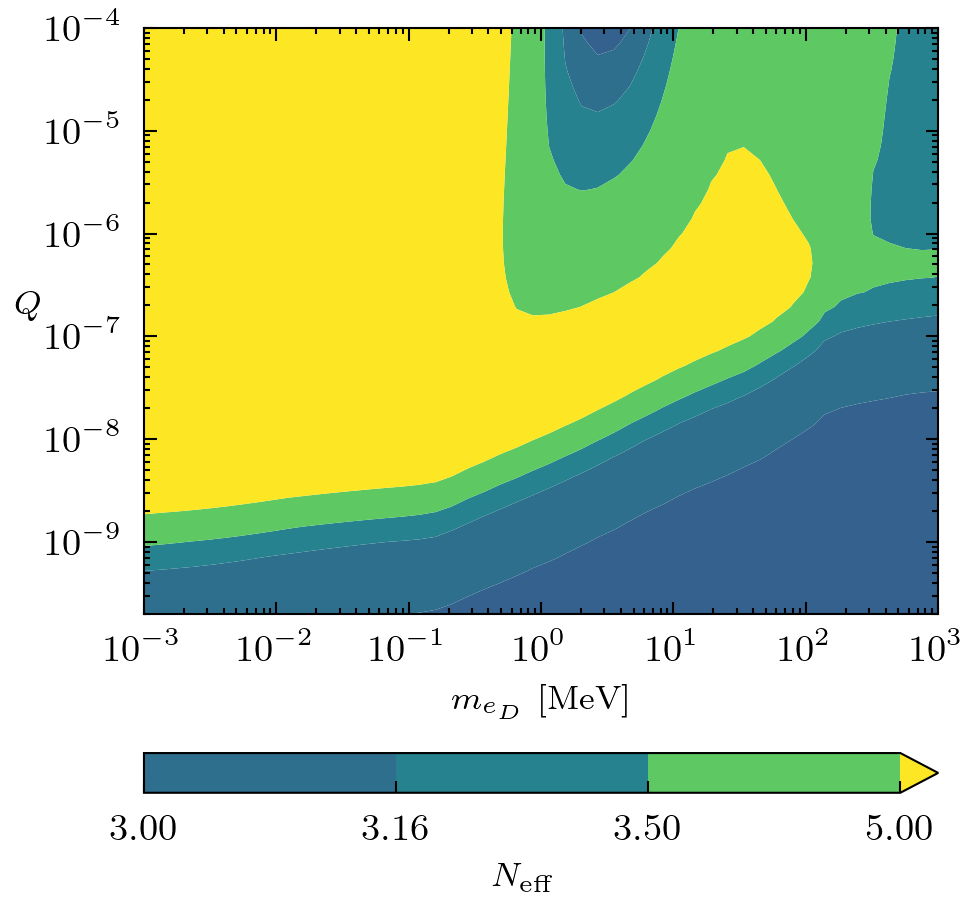

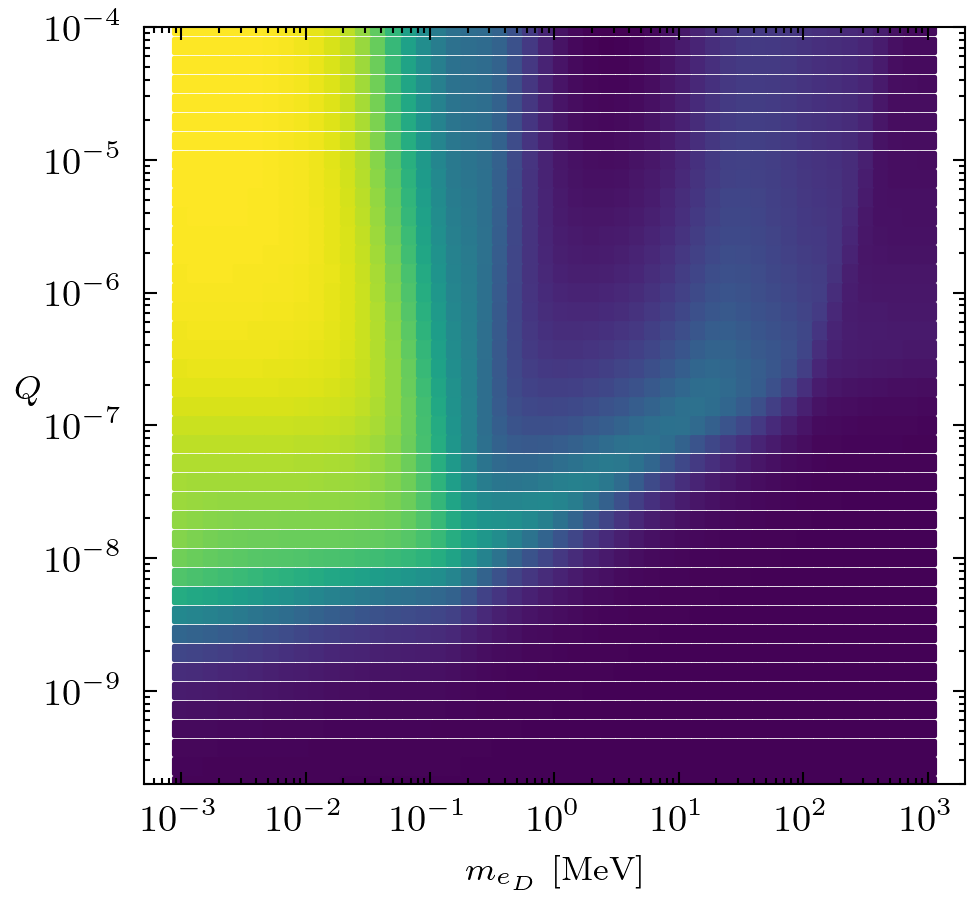

<function matplotlib.pyplot.plot(*args: 'float | ArrayLike | str', scalex: 'bool' = True, scaley: 'bool' = True, data=None, **kwargs) -> 'list[Line2D]'>

In [22]:
plt.rcParams['hatch.color'] = (0.0, 0.0, 0.0, 0.5)
hatch_style = '////'

#figsize=(3.25, 2.0)

f, ax = plt.subplots(
    1, 1, figsize=(3.25, 3.0), layout="constrained"
)
# contour_levels = np.array([3.0, 3.0 + 0.16, 3.5, 4, 5, 7, 10, 15])
# contour_levels = np.array([3.0, 3.0 + 0.16, 3.5, 5])
contour_levels = np.array([2.0, 3.0 - 0.16, 3.0, 3.0 + 0.16, 3.5, 5])

cont_alg = 'serial'

plt.contourf(
    masses_plot, 
    charges_plot,
    N_eff_plot, 
    levels=contour_levels,
    antialiased=True,
    extend='max',
    # cmap='cividis',
    algorithm = cont_alg,
    # colors=['C0', 'C1', 'C2', 'C3', 'C4', 'C5']
    # norm='log',
)

cbar = plt.colorbar(label=r'$N_{\rm eff}$', location='bottom')


bad_sel = np.where(N_eff_plot < 2.4)
plt.plot(masses_plot[bad_sel], charges_plot[bad_sel], linestyle='none', marker='x')


plt.xlabel('$m_{e_D}~$[MeV]')
plt.ylabel(r'$Q$',  rotation='horizontal')

plt.ylim(2e-10, 1e-4)

plt.xscale('log')
plt.yscale('log')
cbar.ax.set_xlim(3.0, 5.0)

plt.savefig('../output/figures/anapole/N_eff_contour_HL.pdf')



plt.show()


plt.rcParams['hatch.color'] = (0.0, 0.0, 0.0, 0.5)
hatch_style = '////'

#figsize=(3.25, 2.0)

f, ax = plt.subplots(
    1, 1, figsize=(3.25, 3.0), layout="constrained"
)
# contour_levels = np.array([3.0, 3.0 + 0.16, 3.5, 4, 5, 7, 10, 15])
# contour_levels = np.array([3.0, 3.0 + 0.16, 3.5, 5])
contour_levels = np.array([2.0, 3.0 - 0.16, 3.0, 3.0 + 0.16, 3.5, 5])

cont_alg = 'serial'

plt.scatter(
    masses_plot, 
    charges_plot,
    c = N_eff_plot,
    s=12.0,
    marker='s',
    norm='log'
)

plt.xscale('log')
plt.yscale('log')


bad_sel = np.where(N_eff_plot < 2.4)
plt.plot(masses_plot[bad_sel], charges_plot[bad_sel], linestyle='none', marker='x', markersize=0.3)


plt.xlabel('$m_{e_D}~$[MeV]')
plt.ylabel(r'$Q$',  rotation='horizontal')

plt.ylim(2e-10, 1e-4)


plt.show()


plt.plot

### Run the results on a finer grid with 2d cubic interpolation

In [23]:
from scipy.interpolate import RegularGridInterpolator, LinearNDInterpolator

In [24]:
_masses_I = np.unique(masses_plot)
_charges_I = np.unique(charges_plot)
_method = 'cubic'

Neff_interp = RegularGridInterpolator((_masses_I, _charges_I), N_eff_plot, method=_method)
R_interp = RegularGridInterpolator((_masses_I, _charges_I), R_plot, method=_method)




Text(0, 0.5, '$q_{\\rm D}$')

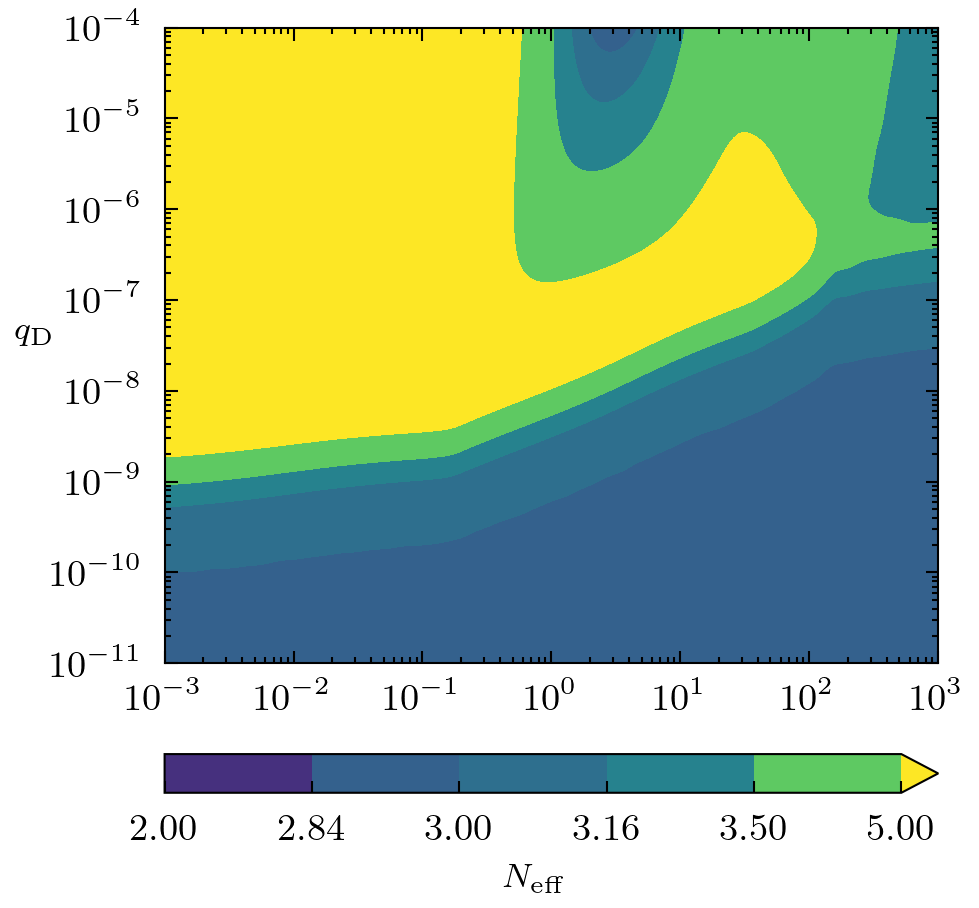

In [25]:
f, ax = plt.subplots(
    1, 1, figsize=(3.25, 3.0), layout="constrained", sharey=False
)


contour_levels = np.array([2.0, 3.0 - 0.16, 3.0, 3.0 + 0.16, 3.5, 5])
# contour_levels = np.array([2.0, act_central_value - 2*Dneff_act_68_errorbar, act_central_value, act_central_value + 2*Dneff_act_68_errorbar, 5]) ## for ACT

Mplot, Qplot = np.meshgrid(
    np.geomspace(np.min(masses_plot), np.max(masses_plot), 300), 
    np.geomspace(1e-11, 1e-4, 300), 
    indexing='ij'
)


cont_quads = plt.contourf(
    Mplot, 
    Qplot,
    Neff_interp((Mplot, Qplot)), 
    levels=contour_levels,
    extend='max'
    # hatches=hatches_PL,
    # **cont_kwargs
)

plt.colorbar(cont_quads, label=r'$N_{\rm eff}$', location='bottom')

# plt.contour(
#     Mplot, 
#     Qplot,
#     PL_Neff_interp((Mplot, Qplot)), 
#     levels=np.array([3.0 - Dneff_constraint, 3.0 + Dneff_constraint]),
#     hatches=hatches_PL,
#     colors='red',
#     **cont_kwargs
# )

plt.ylim(1e-11, 1e-4)
plt.yscale('log')
plt.xscale('log')
plt.ylabel(r'$q_{\rm D}$',  rotation='horizontal')


## 1-d slice at 3 MeV

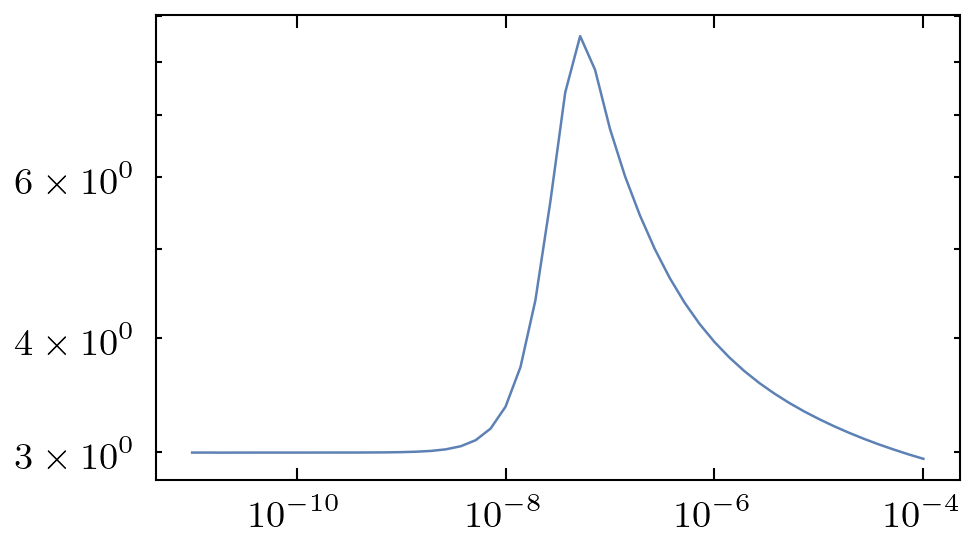

In [26]:
plt.plot(N_eff_results_dict[3.55648][3.55648][0], N_eff_results_dict[3.55648][3.55648][1])
plt.xscale('log')
plt.yscale('log')

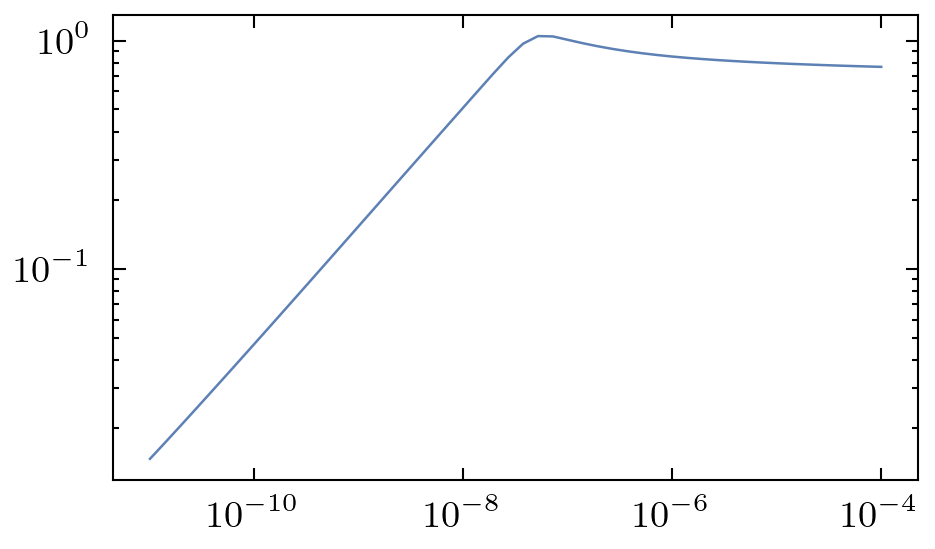

In [57]:
plt.plot(N_eff_results_dict[3.55648][3.55648][0], N_eff_results_dict[3.55648][3.55648][2])
plt.xscale('log')
plt.yscale('log')

## Hot relic abundnaces

In [27]:
def Y_CDM(m_chi):
    return 4.5e-5*(10/m_chi)

In [28]:
R_Tgam_Tdark_interp_dict[m][m](1e-4)

array(0.45015456)

In [29]:
0.056*(1.645611)**3

0.24955689423796507

In [40]:
#I think the way the relic abundance is being calculated is not correct yet

In [41]:
Q_HR = np.zeros(len(unique_m_chi))

for (i,m) in enumerate(unique_m_chi):
    R_interp = R_Tgam_Tdark_interp_dict[m][m]
    Y_HR = lambda Q: 0.056*R_interp(Q)**3
    # print(Y_HR(1e-11))
    # print(Y_HR(1e-4))
    # print(Y_CDM(m))
    # print()

    
    try:
        res = root_scalar(lambda Q: Y_HR(Q) - Y_CDM(m), bracket=(charge_list.min(), charge_list.max()), x0=charge_list.min())
        Q_HR[i] = res.root
    except:
        pass
    

In [45]:
yprime = 0.1
e = 0.3

In [53]:
mdm_hotrelic = load_csv('../input/MDM_DSFO_yp_1e-1_R3_hotrelic.csv')

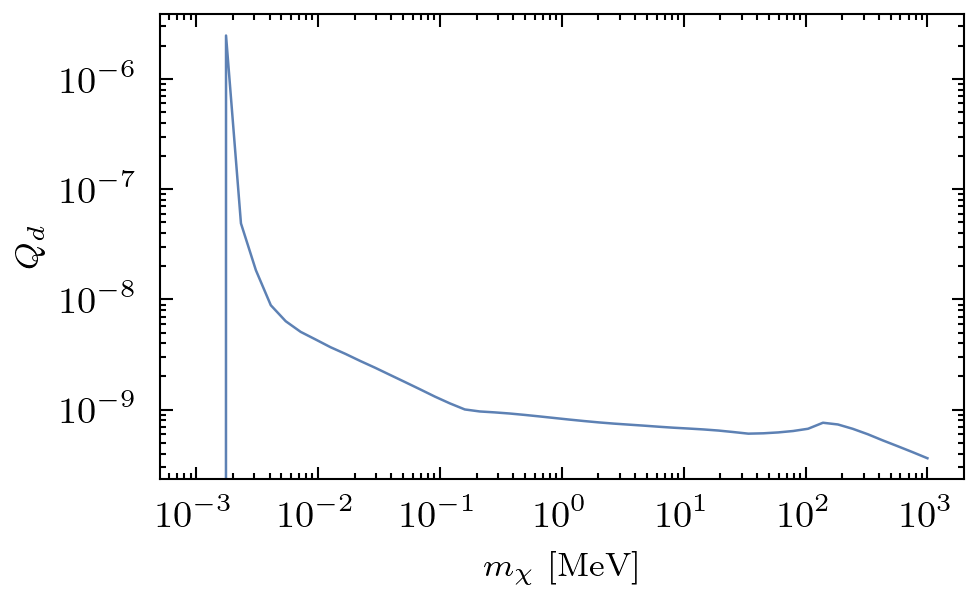

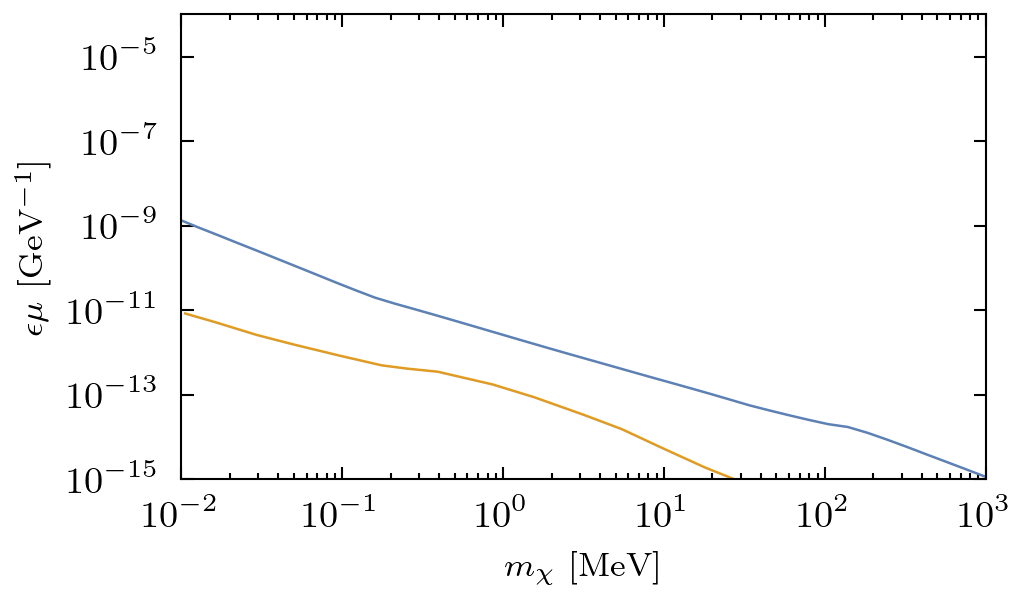

In [56]:
plt.plot(unique_m_chi, Q_HR)
plt.xlabel(r'$m_\chi$ [MeV]')
plt.ylabel('$Q_d$')
plt.xscale('log')
plt.yscale('log')

mdm = Q_HR*e*yprime**2/(32*np.pi**2*3*unique_m_chi)

plt.show()

plt.xlabel(r'$m_\chi$ [MeV]')
plt.ylabel(r'$\epsilon \mu$ [GeV$^{-1}$]')

plt.plot(unique_m_chi, mdm*1e3)

plt.plot(*mdm_hotrelic)
plt.ylim(1e-15, 1e-4)
plt.xlim(1e-2, 1e3)
plt.yscale('log')
plt.xscale('log')


## Paper Quality Neff Contours assuming a central value of 3.01

In [ ]:
plt.rcParams['hatch.color'] = (0.0, 0.0, 0.0, 0.5)
hatch_style = '////'

#figsize=(3.25, 2.0)

f, ax = plt.subplots(
    1, 2, figsize=(2*3.25, 3.0), layout="constrained", sharey=False
)

plt.contourf

cont_kwargs = {
    'algorithm' : 'mpl2014',
    'extend': 'max',
    'antialiased': True
}




################################################################################################################
#Hydrogen limit
################################################################################################################

contour_levels_HL = np.array([2.0, 3.01 - 2*Dneff_act_68_errorbar, 3.0, 3.01 + 2*Dneff_act_68_errorbar, 3.5, 5])
# contour_levels_HL = np.array([2.0, act_central_value  - 2*Dneff_act_68_errorbar, 3.0, act_central_value + 2*Dneff_act_68_errorbar, 3.5, 5])

hatches_HL = [None, hatch_style, None, hatch_style, hatch_style, hatch_style]

contour_lines_HL =  np.array([3.01 - 2*Dneff_act_68_errorbar, 3.01 + 2*Dneff_act_68_errorbar]) #for ACT
# contour_lines_HL =  np.array([act_central_value - 2*Dneff_act_68_errorbar, act_central_value + 2*Dneff_act_68_errorbar]) #for ACT

cont_quads_HL = ax[0].contourf(
    Mplot, 
    Qplot,
    HL_Neff_interp((Mplot, Qplot)), 
    levels=contour_levels_HL,
    **cont_kwargs
)

cbar_HL = plt.colorbar(cont_quads_HL, label=r'$N_{\rm eff}$', location='bottom', ax=ax[0])
cbar_HL.ax.set_xlim(3.0, 5.0)

ax[0].contourf(
    Mplot, 
    Qplot,
    HL_Neff_interp((Mplot, Qplot)), 
    levels=contour_levels_HL,
    hatches=hatches_HL,
    **cont_kwargs
)

ax[0].contour(
    Mplot, 
    Qplot,
    HL_Neff_interp((Mplot, Qplot)), 
    levels=contour_lines_HL,
    colors='red',
    antialiased=True,
)

props = dict(boxstyle='round', facecolor='white', alpha=1.0)

ax[0].text(0.05, 0.95, r'Hydrogen Limit', transform=ax[0].transAxes, fontsize=9,
        verticalalignment='top', bbox=props)

hatch_leg_patch = mpatches.Patch(
    edgecolor='black', 
    facecolor=(0, 0, 0, 0.0), 
    linewidth=0.15, 
    hatch=r'////',
    label=r'$|\Delta N_{\rm eff}| > 0.22$'
)

# ax[0].legend(
#     handles=[hatch_leg_patch],
#     loc='upper left', 
#     bbox_to_anchor=(0.018, 0.883), 
#     edgecolor='black'
# )

################################################################################################################
# Positronium limit
################################################################################################################


contour_levels_PL =  np.array([2.0, 3.01 - 2*Dneff_act_68_errorbar, 3.0, 3.01 + 2*Dneff_act_68_errorbar, 3.5, 5])
# contour_levels_PL =  np.array([2.0, act_central_value - 2*Dneff_act_68_errorbar, 3.0, act_central_value + 2*Dneff_act_68_errorbar, 3.5, 5]) ## for ACT

hatches_PL = [hatch_style, None, None, hatch_style, hatch_style, hatch_style]

contour_lines_PL =  np.array([3.01 - 2*Dneff_act_68_errorbar, 3.01 + 2*Dneff_act_68_errorbar])
# contour_lines_PL =  np.array([act_central_value - 2*Dneff_act_68_errorbar, act_central_value + 2*Dneff_act_68_errorbar]) #for ACT

cont_quads_PL = ax[1].contourf(
    masses_PL, 
    charges_PL,
    N_eff_PL, 
    levels=contour_levels_PL,
    **cont_kwargs
)

cbar_PL = plt.colorbar(cont_quads_HL, label=r'$N_{\rm eff}$', location='bottom', ax=ax[1])
cbar_PL.ax.set_xlim(2.8, 5.0)

ax[1].contourf(
    Mplot, 
    Qplot,
    PL_Neff_interp((Mplot, Qplot)), 
    levels=contour_levels_PL,
    hatches=hatches_PL,
    **cont_kwargs
)

ax[1].contour(
    Mplot, 
    Qplot,
    PL_Neff_interp((Mplot, Qplot)), 
    levels=contour_lines_PL,
    colors='red',
    antialiased=True,
)


################################################################################################################
ax[0].set_ylim(2e-10, 1e-4)
ax[0].set_yscale('log')
ax[0].set_ylabel(r'$q_{\rm D}$',  rotation='horizontal')

ax[1].set_ylim(2e-10, 1e-4)
ax[1].set_yscale('log')

ax[0].set_xlabel(r'$m_{\rm{e_D}}~$[MeV]')
ax[0].set_xscale('log')

ax[1].set_xlabel(r'$m_{\rm{e_D}}~$[MeV]')
ax[1].set_xscale('log')

sn1987a_fid = load_csv('../input/fig/SN1987A_mcp_fiducial.csv')
sn1987a_nakazato = load_csv('../input/fig/SN1987A_mcp_nakazato.csv')

# plt.plot(Mplot, Qplot, color='red', label='ruled out'))

props = dict(boxstyle='round', facecolor='white', alpha=1.0)
ax[1].text(0.05, 0.95, r'Positronium Limit', transform=ax[1].transAxes, fontsize=8,
        verticalalignment='top', bbox=props)

hatch_leg_patch = mpatches.Patch(
    edgecolor='black', 
    facecolor=(0, 0, 0, 0.0), 
    linewidth=0.15, 
    hatch=r'////',
    label=r'$|\Delta N_{\rm eff}| > 0.22$'
)

# dummy_line = ax[1].plot([], [], label='Positronium Limit', linestyle=None, color='None')

# ax[1].legend(
#     handles=[dummy_line[0], hatch_leg_patch],
#     loc='upper left', 
#     # bbox_to_anchor=(0.02, 0.88), 
#     edgecolor='black'
# )

dummy_line = ax[1].plot([], [], label='Positronium Limit', linestyle=None, color='None')

# ax[1].legend(
#     handles=[hatch_leg_patch],
#     loc='upper left', 
#     bbox_to_anchor=(0.018, 0.89), 
#     edgecolor='black'
# )

ax[0].plot(1, 1, color='red', label='Ruled Out')
# ax[0].legend(loc='upper left', bbox_to_anchor=(0.02, 0.88))

# ax[1].scatter(*sn1987a_fid, s=0.4, color='black')
# ax[1].scatter(*sn1987a_nakazato, s=0.4, color='purple')
# ax[1].scatter(sn1987a_nakazato[0], sn1987a_nakazato[1]/np.sqrt(2), s=0.4, color='purple')
ax[1].set_xlim(1e-1, 100)


plt.savefig('../output/figures/N_eff_contour_combined_baseline_act_errors.pdf')
# plt.savefig('../output/figures/N_eff_contour_combined_act_central_act_errors.pdf')

plt.show()

## Paper quality contours for Act central value 2.86

In [ ]:
plt.rcParams['hatch.color'] = (0.0, 0.0, 0.0, 0.5)
hatch_style = '////'

#figsize=(3.25, 2.0)

f, ax = plt.subplots(
    1, 2, figsize=(2*COL_WIDTH, FIG_HEIGHT), layout="constrained", sharey=False
)

plt.contourf

cont_kwargs = {
    'algorithm' : 'mpl2014',
    'extend': 'max',
    'antialiased': True
}


################################################################################################################
#Hydrogen limit
################################################################################################################

# contour_levels_HL = np.array([2.0, 3.01 - 2*Dneff_act_68_errorbar, 3.0, 3.01 + 2*Dneff_act_68_errorbar, 3.5, 5])
contour_levels_HL = np.array([2.0, act_central_value  - 2*Dneff_act_68_errorbar, 3.0, act_central_value + 2*Dneff_act_68_errorbar, 3.5, 5])

hatches_HL = [None, hatch_style, None, hatch_style, hatch_style, hatch_style]

# contour_lines_HL =  np.array([3.01 - 2*Dneff_act_68_errorbar, 3.01 + 2*Dneff_act_68_errorbar]) #for ACT
contour_lines_HL =  np.array([act_central_value - 2*Dneff_act_68_errorbar, act_central_value + 2*Dneff_act_68_errorbar]) #for ACT

cont_quads_HL = ax[0].contourf(
    Mplot, 
    Qplot,
    HL_Neff_interp((Mplot, Qplot)), 
    levels=contour_levels_HL,
    **cont_kwargs
)

cbar_HL = plt.colorbar(cont_quads_HL, label=r'$N_{\rm eff}$', location='bottom', ax=ax[0])
cbar_HL.ax.set_xlim(3.0, 5.0)

ax[0].contourf(
    Mplot, 
    Qplot,
    HL_Neff_interp((Mplot, Qplot)), 
    levels=contour_levels_HL,
    hatches=hatches_HL,
    **cont_kwargs
)

ax[0].contour(
    Mplot, 
    Qplot,
    HL_Neff_interp((Mplot, Qplot)), 
    levels=contour_lines_HL,
    colors='red',
    antialiased=True,
)

props = dict(boxstyle='round', facecolor='white', alpha=1.0)

ax[0].text(0.05, 0.95, r'Hydrogen Limit', transform=ax[0].transAxes, fontsize=9,
        verticalalignment='top', bbox=props)

hatch_leg_patch = mpatches.Patch(
    edgecolor='black', 
    facecolor=(0, 0, 0, 0.0), 
    linewidth=0.15, 
    hatch=r'////',
    label=r'$|\Delta N_{\rm eff}| > 0.22$'
)

# ax[0].legend(
#     handles=[hatch_leg_patch],
#     loc='upper left', 
#     bbox_to_anchor=(0.018, 0.883), 
#     edgecolor='black'
# )

################################################################################################################
# Positronium limit
################################################################################################################


# contour_levels_PL =  np.array([2.0, 3.01 - 2*Dneff_act_68_errorbar, 3.0, 3.01 + 2*Dneff_act_68_errorbar, 3.5, 5])
contour_levels_PL =  np.array([2.0, act_central_value - 2*Dneff_act_68_errorbar, 3.0, act_central_value + 2*Dneff_act_68_errorbar, 3.5, 5]) ## for ACT

hatches_PL = [hatch_style, None, None, hatch_style, hatch_style, hatch_style]

# contour_lines_PL =  np.array([3.01 - 2*Dneff_act_68_errorbar, 3.01 + 2*Dneff_act_68_errorbar])
contour_lines_PL =  np.array([act_central_value - 2*Dneff_act_68_errorbar, act_central_value + 2*Dneff_act_68_errorbar]) #for ACT

cont_quads_PL = ax[1].contourf(
    masses_PL, 
    charges_PL,
    N_eff_PL, 
    levels=contour_levels_PL,
    **cont_kwargs
)

cbar_PL = plt.colorbar(cont_quads_HL, label=r'$N_{\rm eff}$', location='bottom', ax=ax[1])
cbar_PL.ax.set_xlim(2.0, 5.0)

ax[1].contourf(
    Mplot, 
    Qplot,
    PL_Neff_interp((Mplot, Qplot)), 
    levels=contour_levels_PL,
    hatches=hatches_PL,
    **cont_kwargs
)

ax[1].contour(
    Mplot, 
    Qplot,
    PL_Neff_interp((Mplot, Qplot)), 
    levels=contour_lines_PL,
    colors='red',
    antialiased=True,
)


################################################################################################################
ax[0].set_ylim(2e-10, 1e-4)
ax[0].set_yscale('log')
ax[0].set_ylabel(r'$q_{\rm D}$',  rotation='horizontal')

ax[1].set_ylim(2e-10, 1e-4)
ax[1].set_yscale('log')

ax[0].set_xlabel(r'$m_{\rm{e_D}}~$[MeV]')
ax[0].set_xscale('log')

ax[1].set_xlabel(r'$m_{\rm{e_D}}~$[MeV]')
ax[1].set_xscale('log')

sn1987a_fid = load_csv('../input/fig/SN1987A_mcp_fiducial.csv')
sn1987a_nakazato = load_csv('../input/fig/SN1987A_mcp_nakazato.csv')

# plt.plot(Mplot, Qplot, color='red', label='ruled out'))

props = dict(boxstyle='round', facecolor='white', alpha=1.0)
ax[1].text(0.05, 0.95, r'Positronium Limit', transform=ax[1].transAxes, fontsize=8,
        verticalalignment='top', bbox=props)

hatch_leg_patch = mpatches.Patch(
    edgecolor='black', 
    facecolor=(0, 0, 0, 0.0), 
    linewidth=0.15, 
    hatch=r'////',
    label=r'$|\Delta N_{\rm eff}| > 0.22$'
)

# dummy_line = ax[1].plot([], [], label='Positronium Limit', linestyle=None, color='None')

# ax[1].legend(
#     handles=[dummy_line[0], hatch_leg_patch],
#     loc='upper left', 
#     # bbox_to_anchor=(0.02, 0.88), 
#     edgecolor='black'
# )

dummy_line = ax[1].plot([], [], label='Positronium Limit', linestyle=None, color='None')

# ax[1].legend(
#     handles=[hatch_leg_patch],
#     loc='upper left', 
#     bbox_to_anchor=(0.018, 0.89), 
#     edgecolor='black'
# )

ax[0].plot(1, 1, color='red', label='Ruled Out')
# ax[0].legend(loc='upper left', bbox_to_anchor=(0.02, 0.88))

# ax[1].scatter(*sn1987a_fid, s=0.4, color='black')
# ax[1].scatter(*sn1987a_nakazato, s=0.4, color='purple')
# ax[1].scatter(sn1987a_nakazato[0], sn1987a_nakazato[1]/np.sqrt(2), s=0.4, color='purple')
ax[1].set_xlim(1e-1, 100)


# plt.savefig('../output/figures/N_eff_contour_combined_baseline_act_errors.pdf')
plt.savefig('../output/figures/N_eff_contour_combined_act_central_act_errors.pdf')

plt.show()

In [ ]:
plt.rcParams['hatch.color'] = (0.0, 0.0, 0.0, 0.5)
hatch_style = '////'

#figsize=(3.25, 2.0)

f, ax = plt.subplots(
    1, 2, figsize=(2*3.25, 3.0), layout="constrained", sharey=False
)

plt.contourf

cont_kwargs = {
    'algorithm' : 'mpl2014',
    'extend': 'max',
    'antialiased': True
}



################################################################################################################
#Hydrogen limit
################################################################################################################

# contour_levels_HL = np.array([2.0, 3.01 - 2*Dneff_act_68_errorbar, 3.0, 3.01 + 2*Dneff_act_68_errorbar, 3.5, 5])
contour_levels_HL = np.array([2.0, act_central_value  - 2*Dneff_act_68_errorbar, act_central_value, act_central_value + 2*Dneff_act_68_errorbar, 5])

hatches_HL = [None, hatch_style, None, hatch_style,  hatch_style]

# contour_lines_HL =  np.array([3.01 - 2*Dneff_act_68_errorbar, 3.01 + 2*Dneff_act_68_errorbar]) #for ACT
contour_lines_HL =  np.array([act_central_value - 2*Dneff_act_68_errorbar, act_central_value + 2*Dneff_act_68_errorbar]) #for ACT

cont_quads_HL = ax[0].contourf(
    Mplot, 
    Qplot,
    HL_Neff_interp((Mplot, Qplot)), 
    levels=contour_levels_HL,
    **cont_kwargs
)

cbar_HL = plt.colorbar(cont_quads_HL, label=r'$N_{\rm eff}$', location='bottom', ax=ax[0])
cbar_HL.ax.set_xlim(2.0, 5.0)

ax[0].contourf(
    Mplot, 
    Qplot,
    HL_Neff_interp((Mplot, Qplot)), 
    levels=contour_levels_HL,
    hatches=hatches_HL,
    **cont_kwargs
)

ax[0].contour(
    Mplot, 
    Qplot,
    HL_Neff_interp((Mplot, Qplot)), 
    levels=contour_lines_HL,
    colors='red',
    antialiased=True,
)

props = dict(boxstyle='round', facecolor='white', alpha=1.0)

ax[0].text(0.05, 0.95, r'Hydrogen Limit', transform=ax[0].transAxes, fontsize=8,
        verticalalignment='top', bbox=props)

hatch_leg_patch = mpatches.Patch(
    edgecolor='black', 
    facecolor=(0, 0, 0, 0.0), 
    linewidth=0.15, 
    hatch=r'////',
    label=r'$|\Delta N_{\rm eff}| > 0.22$'
)

################################################################################################################
# Positronium limit
################################################################################################################


# contour_levels_PL =  np.array([2.0, 3.01 - 2*Dneff_act_68_errorbar, 3.0, 3.01 + 2*Dneff_act_68_errorbar, 3.5, 5])
contour_levels_PL =  np.array([2.0, act_central_value - 2*Dneff_act_68_errorbar, act_central_value, act_central_value + 2*Dneff_act_68_errorbar, 5]) ## for ACT

hatches_PL = [hatch_style, None, None, hatch_style, hatch_style]

# contour_lines_PL =  np.array([3.01 - 2*Dneff_act_68_errorbar, 3.01 + 2*Dneff_act_68_errorbar])
contour_lines_PL =  np.array([act_central_value - 2*Dneff_act_68_errorbar, act_central_value + 2*Dneff_act_68_errorbar]) #for ACT

cont_quads_PL = ax[1].contourf(
    masses_PL, 
    charges_PL,
    N_eff_PL, 
    levels=contour_levels_PL,
    **cont_kwargs
)

cbar_PL = plt.colorbar(cont_quads_HL, label=r'$N_{\rm eff}$', location='bottom', ax=ax[1])
cbar_PL.ax.set_xlim(2.0, 5.0)

ax[1].contourf(
    Mplot, 
    Qplot,
    PL_Neff_interp((Mplot, Qplot)), 
    levels=contour_levels_PL,
    hatches=hatches_PL,
    **cont_kwargs
)

ax[1].contour(
    Mplot, 
    Qplot,
    PL_Neff_interp((Mplot, Qplot)), 
    levels=contour_lines_PL,
    colors='red',
    antialiased=True,
)


################################################################################################################
ax[0].set_ylim(2e-10, 1e-4)
ax[0].set_yscale('log')
ax[0].set_ylabel(r'$q_{\rm D}$',  rotation='horizontal')

ax[1].set_ylim(2e-10, 1e-4)
ax[1].set_yscale('log')

ax[0].set_xlabel(r'$m_{\rm{e_D}}~$[MeV]')
ax[0].set_xscale('log')

ax[1].set_xlabel(r'$m_{\rm{e_D}}~$[MeV]')
ax[1].set_xscale('log')

sn1987a_fid = load_csv('../input/fig/SN1987A_mcp_fiducial.csv')
sn1987a_nakazato = load_csv('../input/fig/SN1987A_mcp_nakazato.csv')

# plt.plot(Mplot, Qplot, color='red', label='ruled out'))

props = dict(boxstyle='round', facecolor='white', alpha=1.0)
ax[1].text(0.05, 0.95, r'Positronium Limit', transform=ax[1].transAxes, fontsize=8,
        verticalalignment='top', bbox=props)

ax[0].plot(1, 1, color='red', label='Ruled Out')
# ax[0].legend(loc='upper left', bbox_to_anchor=(0.02, 0.88))

# ax[1].scatter(sn1987a_fid[0][80:], sn1987a_fid[1][80:], s=0.4, color='black')
# ax[1].scatter(sn1987a_fid[0][0:80], sn1987a_fid[1][0:80]/np.sqrt(2), s=0.4, color='black')
# ax[1].scatter(*sn1987a_nakazato, s=0.4, color='purple')
# ax[1].scatter(sn1987a_nakazato[0], sn1987a_nakazato[1]/np.sqrt(2), s=0.4, color='purple')
ax[1].set_xlim(1e-1, 100)


f.add_artist(lines.Line2D([0.1738, 0.1738], [-0.02, 0.0], color='black'))
f.add_artist(lines.Line2D([0.3708, 0.3708], [-0.02, 0.0], color='black'))
f.add_artist(lines.Line2D([0.1738, 0.3708], [-0.01, -0.01], color='black'))

f.add_artist(lines.Line2D([0.1738, 0.1738], [0.1238, 0.1638], color='red'))
f.add_artist(lines.Line2D([0.3708, 0.3708], [0.1238, 0.1638], color='red'))

f.text(0.21, -0.05, r'ACT $2\sigma$ allowed', fontsize=8)

dx1 = .4908
dx2 = .4909

f.add_artist(lines.Line2D([0.1738 + dx1, 0.1738 + dx1], [-0.02, 0.0], color='black'))
f.add_artist(lines.Line2D([0.3708 + dx2, 0.3708 + dx2], [-0.02, 0.0], color='black'))
f.add_artist(lines.Line2D([0.1738 + dx1, 0.3708 + dx2], [-0.01, -0.01], color='black'))

f.add_artist(lines.Line2D([0.1738 + dx1, 0.1738 + dx2], [0.1238, 0.1638], color='red'))
f.add_artist(lines.Line2D([0.3708 + dx2, 0.3708 + dx2], [0.1238, 0.1638], color='red'))

f.text(0.21 + dx1, -0.05, r'ACT $2\sigma$ allowed', fontsize=8)


# plt.savefig('../output/figures/N_eff_contour_combined_baseline_act_errors.pdf')
plt.savefig('../output/figures/N_eff_contour_combined_act_central_act_errors.pdf')

plt.show()

In [ ]:
central_value_he4 = 3.044

errorbar_1sig_he4 = 0.027/2

plt.rcParams['hatch.color'] = (0.0, 0.0, 0.0, 0.5)
hatch_style = '////'

#figsize=(3.25, 2.0)

f, ax = plt.subplots(
    1, 2, figsize=(2*3.25, 3.0), layout="constrained", sharey=False
)

plt.contourf

cont_kwargs = {
    'algorithm' : 'mpl2014',
    'extend': 'max',
    'antialiased': True
}



################################################################################################################
#Hydrogen limit
################################################################################################################

# contour_levels_HL = np.array([2.0, 3.04 - 2*Dneff_act_68_errorbar, 3.04, 3.04 + 2*Dneff_act_68_errorbar, 5])
contour_levels_HL = np.array([2.0, central_value_he4 - 2*errorbar_1sig_he4, central_value_he4, central_value_he4+ 2*errorbar_1sig_he4 , 5])

# contour_levels_HL = np.array([2.0, act_central_value  - 2*Dneff_act_68_errorbar, act_central_value, act_central_value + 2*Dneff_act_68_errorbar, 5])

hatches_HL = [hatch_style, None, None, hatch_style,  hatch_style]

contour_lines_HL =  np.array([central_value_he4 - 2*errorbar_1sig_he4, central_value_he4 + 2*errorbar_1sig_he4]) #for ACT
# contour_lines_HL =  np.array([act_central_value - 2*Dneff_act_68_errorbar, act_central_value + 2*Dneff_act_68_errorbar]) #for ACT

cont_quads_HL = ax[0].contourf(
    Mplot, 
    Qplot,
    HL_Neff_interp((Mplot, Qplot)), 
    levels=contour_levels_HL,
    **cont_kwargs
)

cbar_HL = plt.colorbar(cont_quads_HL, label=r'$N_{\rm eff}$', location='bottom', ax=ax[0])
cbar_HL.ax.set_xlim(2.0, 5.0)

ax[0].contourf(
    Mplot, 
    Qplot,
    HL_Neff_interp((Mplot, Qplot)), 
    levels=contour_levels_HL,
    hatches=hatches_HL,
    **cont_kwargs
)

ax[0].contour(
    Mplot, 
    Qplot,
    HL_Neff_interp((Mplot, Qplot)), 
    levels=contour_lines_HL,
    colors='red',
    antialiased=True,
)

props = dict(boxstyle='round', facecolor='white', alpha=1.0)

ax[0].text(0.05, 0.95, r'Hydrogen Limit', transform=ax[0].transAxes, fontsize=8,
        verticalalignment='top', bbox=props)

hatch_leg_patch = mpatches.Patch(
    edgecolor='black', 
    facecolor=(0, 0, 0, 0.0), 
    linewidth=0.15, 
    hatch=r'////',
    label=r'$|\Delta N_{\rm eff}| > 0.22$'
)

################################################################################################################
# Positronium limit
################################################################################################################


contour_levels_PL =  np.array([2.0, central_value_he4 - 2*errorbar_1sig_he4, central_value_he4, central_value_he4 + 2*errorbar_1sig_he4, 5])
# contour_levels_PL =  np.array([2.0, act_central_value - 2*Dneff_act_68_errorbar, act_central_value, act_central_value + 2*Dneff_act_68_errorbar, 5]) ## for ACT

hatches_PL = [hatch_style, None, None, hatch_style, hatch_style]

contour_lines_PL =  np.array([central_value_he4 - 2*errorbar_1sig_he4, central_value_he4 + 2*errorbar_1sig_he4])
# contour_lines_PL =  np.array([act_central_value - 2*Dneff_act_68_errorbar, act_central_value + 2*Dneff_act_68_errorbar]) #for ACT

cont_quads_PL = ax[1].contourf(
    masses_PL, 
    charges_PL,
    N_eff_PL, 
    levels=contour_levels_PL,
    **cont_kwargs
)

cbar_PL = plt.colorbar(cont_quads_HL, label=r'$N_{\rm eff}$', location='bottom', ax=ax[1])
cbar_PL.ax.set_xlim(2.0, 5.0)

ax[1].contourf(
    Mplot, 
    Qplot,
    PL_Neff_interp((Mplot, Qplot)) + 0.03, 
    levels=contour_levels_PL,
    hatches=hatches_PL,
    **cont_kwargs
)

ax[1].contour(
    Mplot, 
    Qplot,
    PL_Neff_interp((Mplot, Qplot))+ 0.03, 
    levels=contour_lines_PL,
    colors='red',
    antialiased=True,
)


################################################################################################################
ax[0].set_ylim(2e-10, 1e-4)
ax[0].set_yscale('log')
ax[0].set_ylabel(r'$q_{\rm D}$',  rotation='horizontal')

ax[1].set_ylim(1e-10, 1e-4)
ax[1].set_yscale('log')

ax[0].set_xlabel(r'$m_{\rm{e_D}}~$[MeV]')
ax[0].set_xscale('log')

ax[1].set_xlabel(r'$m_{\rm{e_D}}~$[MeV]')
ax[1].set_xscale('log')

sn1987a_fid = load_csv('../input/fig/SN1987A_mcp_fiducial.csv')
sn1987a_nakazato = load_csv('../input/fig/SN1987A_mcp_nakazato.csv')

# plt.plot(Mplot, Qplot, color='red', label='ruled out'))

props = dict(boxstyle='round', facecolor='white', alpha=1.0)
ax[1].text(0.05, 0.95, r'Positronium Limit', transform=ax[1].transAxes, fontsize=8,
        verticalalignment='top', bbox=props)

ax[0].plot(1, 1, color='red', label='Ruled Out')
# ax[0].legend(loc='upper left', bbox_to_anchor=(0.02, 0.88))

# ax[1].scatter(sn1987a_fid[0][80:], sn1987a_fid[1][80:], s=0.4, color='black')
# ax[1].scatter(sn1987a_fid[0][0:80], sn1987a_fid[1][0:80]/np.sqrt(2), s=0.4, color='black')
# ax[1].scatter(*sn1987a_nakazato, s=0.4, color='purple')
# ax[1].scatter(sn1987a_nakazato[0], sn1987a_nakazato[1]/np.sqrt(2), s=0.4, color='purple')
ax[1].set_xlim(1e-1, 100)


f.add_artist(lines.Line2D([0.1738, 0.1738], [-0.02, 0.0], color='black'))
f.add_artist(lines.Line2D([0.3708, 0.3708], [-0.02, 0.0], color='black'))
f.add_artist(lines.Line2D([0.1738, 0.3708], [-0.01, -0.01], color='black'))

f.add_artist(lines.Line2D([0.1738, 0.1738], [0.1238, 0.1638], color='red'))
f.add_artist(lines.Line2D([0.3708, 0.3708], [0.1238, 0.1638], color='red'))

f.text(0.21, -0.05, r'BBN $2\sigma$ allowed', fontsize=8)

dx1 = .4908
dx2 = .4909

f.add_artist(lines.Line2D([0.1738 + dx1, 0.1738 + dx1], [-0.02, 0.0], color='black'))
f.add_artist(lines.Line2D([0.3708 + dx2, 0.3708 + dx2], [-0.02, 0.0], color='black'))
f.add_artist(lines.Line2D([0.1738 + dx1, 0.3708 + dx2], [-0.01, -0.01], color='black'))

f.add_artist(lines.Line2D([0.1738 + dx1, 0.1738 + dx2], [0.1238, 0.1638], color='red'))
f.add_artist(lines.Line2D([0.3708 + dx2, 0.3708 + dx2], [0.1238, 0.1638], color='red'))

f.text(0.21 + dx1, -0.05, r'BBN $2\sigma$ allowed', fontsize=8)


plt.savefig('../output/figures/N_eff_contour_BBN.pdf')
# plt.savefig('../output/figures/N_eff_contour_combined_act_central_act_errors.pdf')

plt.show()

In [ ]:
charges

In [ ]:
PL_Neff_interp((100, 1e-10))

## Save interpolated results

In [ ]:
resname_HL_interpolated = 'neff_scan_result_HL_interp.npz'
resname_PL_interpolated  = 'neff_scan_result_PL_interp.npz'
np.savez_compressed(
    os.path.join('../output/results/',resname_HL_interpolated ),
    m_de = Mplot,
    m_dp = 1000*Mplot,
    charge = Qplot,
    N_eff = HL_Neff_interp((Mplot, Qplot)),
    R_Tdark_Tgam = HL_R_interp((Mplot, Qplot))
)

np.savez_compressed(
    os.path.join('../output/results/',resname_PL_interpolated),
    m_de = Mplot,
    m_dp = Mplot,
    charge = Qplot,
    N_eff = PL_Neff_interp((Mplot, Qplot)),
    R_Tdark_Tgam = PL_R_interp((Mplot, Qplot))
    
)

### Interpolated results at fixed mPD for plots

## paper quality plot showing 1d slice of Neff at fixed m_de with multiple curves for different m_dp

In [ ]:
from scipy.interpolate import make_smoothing_spline

In [ ]:
f, ax = plt.subplots(
    1, 1, figsize=(3.25, 2.0), layout="constrained"
)


m_de_plot = unique_mde[28] # ~5 MeV for paper
# m_de_plot = unique_mde[49]

results_keys = np.array(list(N_eff_results_dict[m_de_plot].keys()))
# keys_to_run = np.array([0, 1, 9, 12, 13], dtype=int)
keys_to_run = np.array([0, 1, 2, 9, 13], dtype=int) #for paper
# keys_to_run = np.array([0], dtype=int)

for m_dp in results_keys[keys_to_run]:
    charges_plot = N_eff_results_dict[m_de_plot][m_dp][0]
    N_eff_plot = N_eff_results_dict[m_de_plot][m_dp][1]

    res_I = interp1d(charges_plot, N_eff_plot, kind='cubic')
    charges_fine = np.geomspace(charges_plot[0], charges_plot[-1], 100)
    
    # plt.plot(charges_plot, N_eff_plot, label=f'{m_dp/m_de_plot:.2f}')
    plt.plot(charges_fine, res_I(charges_fine), label=r'$m_{\rm{p_D}}$= '+f'{m_dp/m_de_plot:.0f}' + r'$\times m_{\rm{e_D}}$')
    # plt.plot(charges_plot, N_eff_plot)

plt.xscale('log')
plt.xlabel(r'$q_{\rm D}$')
plt.ylabel(r'$N_{\rm eff}$')
plt.legend(loc=1, framealpha=0.0)
# plt.title(f'Dark Electron Mass: {m_de_plot:.2e} MeV')

plt.fill_between(charges_fine, 
                 act_central_value - 2*Dneff_act_68_errorbar, 
                 act_central_value + 2*Dneff_act_68_errorbar, 
                 color='gray', 
                 alpha=0.5,
                 edgecolor=None          
                )
plt.grid(which='both', axis='x', linestyle='solid', alpha=0.25)
plt.grid(which='both', axis='y', linestyle='solid', alpha=0.25)
plt.xlim(charges_fine[0], charges_fine[-1])
plt.ylim(2.5, 6.2)
plt.xlim(3e-10, 9e-5)

# plt.ylim(3.105, 3.115)
# plt.xlim(1e-8, 2e-8)

plt.yscale('log')
# plt.savefig('../output/figures/N_eff_1d_slice_m_de_5.18.pdf')
plt.show()

In [ ]:
res_I(charges_plot)

In [ ]:
np.array(list(N_eff_results_dict[m_de_plot].keys()))

In [ ]:
results_keys/m_de_plot

In [ ]:
print(m_de_plot)

In [ ]:
 unique_mde[28]